# MSFT Hisse Verisi - İlk Keşifsel Veri Analizi

Bu notebook, Microsoft (`MSFT`) günlük hisse verisinin yapısını ve temel özelliklerini anlamak için hazırlanmıştır. Bu aşamada modelleme, veri bölme veya ölçekleme yapılmaz.

**İncelenecek konular:**

- Veri kaynağı ve kullanılan veri kesiti
- Sütunlar ve veri tipleri
- Eksik ve tekrarlı gözlem kontrolleri
- Temel istatistikler
- Düzeltilmiş kapanış fiyatı ve işlem hacminin zaman içindeki görünümü

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Veri dosyalarının bulunması

Notebook hem proje kökünden hem de `notebooks/` klasöründen çalıştırılabilir. Ham CSV Git'e eklenmez; metadata dosyası kullanılan veri kesitini tanımlar.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u proje içinde çalıştırın.")

DATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.csv"
METADATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.metadata.json"

if not DATA_PATH.exists():
    raise FileNotFoundError("Ham veri bulunamadı. Önce `uv run download-msft-data` çalıştırın.")

print(f"Proje kökü: {PROJECT_ROOT}")
print(f"Veri dosyası: {DATA_PATH}")

Proje kökü: C:\Users\brkbs\Desktop\Stock_Price_Prediction
Veri dosyası: C:\Users\brkbs\Desktop\Stock_Price_Prediction\data\raw\msft_daily_latest.csv


In [3]:
data = pd.read_csv(DATA_PATH, parse_dates=["Date"], index_col="Date").sort_index()
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

print(f"Veri boyutu: {data.shape[0]:,} satır x {data.shape[1]} sütun")
display(pd.Series(metadata, name="Değer").to_frame())

Veri boyutu: 4,156 satır x 5 sütun


,Değer
ticker,MSFT
source,Yahoo Finance via yfinance
interval,1d
auto_adjust,True
start_inclusive,2010-01-01
end_exclusive,2026-07-15
first_observation,2010-01-04
last_observation,2026-07-14
rows,4156
columns,"[Open, High, Low, Close, Volume]"


## 2. Sütunların anlamı

- **Open:** Günün düzeltilmiş açılış fiyatı
- **High:** Gün içindeki düzeltilmiş en yüksek fiyat
- **Low:** Gün içindeki düzeltilmiş en düşük fiyat
- **Close:** Günün düzeltilmiş kapanış fiyatı ve ilk modelimizin hedef değişkeni
- **Volume:** Günlük işlem gören hisse adedi

Fiyatların otomatik düzeltilmiş olması, temettü ve hisse bölünmesi gibi şirket işlemlerinin uzun dönem grafiğinde yapay sıçramalar oluşturmasını azaltır.

In [4]:
print("İlk beş gözlem:")
display(data.head())

print("Son beş gözlem:")
display(data.tail())

İlk beş gözlem:


,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,22.7820,23.1391,22.7597,23.0275,38409100
2010-01-05,22.9531,23.1391,22.7969,23.0349,49749600
2010-01-06,22.9754,23.1242,22.7076,22.8936,58182400
2010-01-07,22.7894,22.8415,22.4621,22.6555,50559700
2010-01-08,22.5290,22.9754,22.4993,22.8117,51197400


Son beş gözlem:


,Open,High,Low,Close,Volume
Date,,,,,
2026-07-08,384.0300,385.3100,381.3300,383.3400,25908300
2026-07-09,374.4500,384.6500,373.3500,384.3600,31083200
2026-07-10,387.8000,391.9100,381.5000,385.1000,24644600
2026-07-13,387.7500,393.6500,384.1500,390.9900,28914900
2026-07-14,382.8200,388.1900,378.6500,384.9300,27820600


In [5]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4156 entries, 2010-01-04 to 2026-07-14
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    4156 non-null   float64
 1   High    4156 non-null   float64
 2   Low     4156 non-null   float64
 3   Close   4156 non-null   float64
 4   Volume  4156 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 194.8 KB


## 3. Veri kalitesi kontrolleri

Zaman serisinde tarih sırası, benzersiz tarihler ve eksiksiz hedef değerleri model hazırlığından önce doğrulanmalıdır.

In [6]:
quality_summary = pd.Series(
    {
        "Gözlem sayısı": len(data),
        "İlk tarih": data.index.min().date(),
        "Son tarih": data.index.max().date(),
        "Eksik değer sayısı": int(data.isna().sum().sum()),
        "Tekrarlı tarih sayısı": int(data.index.duplicated().sum()),
        "Tarihler kronolojik mi?": data.index.is_monotonic_increasing,
    },
    name="Sonuç",
)

assert data.index.is_monotonic_increasing
assert not data.index.has_duplicates
assert not data.isna().any().any()

quality_summary.to_frame()

,Sonuç
Gözlem sayısı,4156
İlk tarih,2010-01-04
Son tarih,2026-07-14
Eksik değer sayısı,0
Tekrarlı tarih sayısı,0
Tarihler kronolojik mi?,True


## 4. Temel istatistikler

Aşağıdaki tablo her sütunun dağılımını özetler. Fiyat seviyelerinin uzun yıllar boyunca değişmesi nedeniyle bu değerler tek başına model performansı hakkında bilgi vermez; yalnızca veri ölçeğini anlamamıza yardım eder.

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,"4,156.0000",157.2056,149.7206,17.3377,31.4613,86.7558,270.0124,550.8302
High,"4,156.0000",158.6820,151.0438,17.5104,31.7381,87.5285,273.6264,551.0485
Low,"4,156.0000",155.6419,148.2628,17.0674,31.2405,85.6347,266.8886,537.3668
Close,"4,156.0000",157.2257,149.6980,17.2776,31.4778,86.4384,269.4901,538.6586
Volume,"4,156.0000","35,366,760.8999","20,529,057.8044","5,855,900.0000","22,178,775.0000","29,630,250.0000","43,140,400.0000","319,317,900.0000"


## 5. Düzeltilmiş kapanış fiyatı

Uzun dönem grafiği genel eğilimi, düşüş dönemlerini ve fiyat ölçeğinin zaman içinde nasıl değiştiğini görmemizi sağlar.

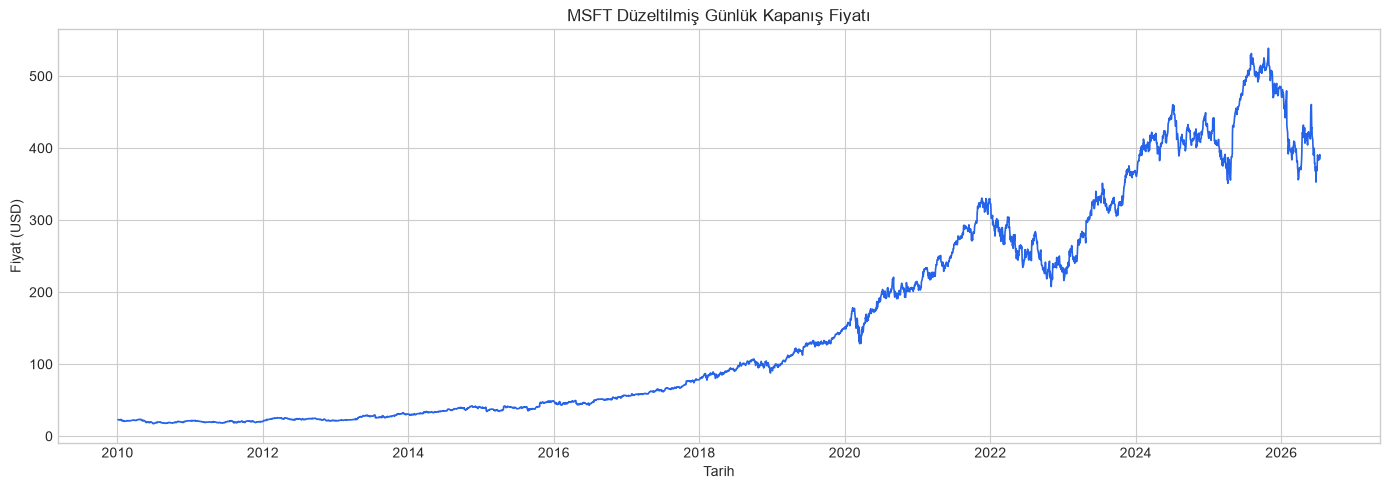

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data.index, data["Close"], color="#2563EB", linewidth=1.2)
ax.set(
    title="MSFT Düzeltilmiş Günlük Kapanış Fiyatı",
    xlabel="Tarih",
    ylabel="Fiyat (USD)",
)
fig.tight_layout()
plt.show()

In [9]:
close_summary = pd.Series(
    {
        "En düşük kapanış": data["Close"].min(),
        "En düşük kapanış tarihi": data["Close"].idxmin().date(),
        "En yüksek kapanış": data["Close"].max(),
        "En yüksek kapanış tarihi": data["Close"].idxmax().date(),
        "Son kapanış": data["Close"].iloc[-1],
    },
    name="Değer",
)
close_summary.to_frame()

,Değer
En düşük kapanış,17.2776
En düşük kapanış tarihi,2010-06-30
En yüksek kapanış,538.6586
En yüksek kapanış tarihi,2025-10-28
Son kapanış,384.9300


## 6. İşlem hacmi

Hacim, fiyat kadar kalıcı bir trend göstermeyebilir; belirli dönemlerde piyasa ilgisinin ve hareketliliğin arttığını gösteren sıçramalar içerebilir.

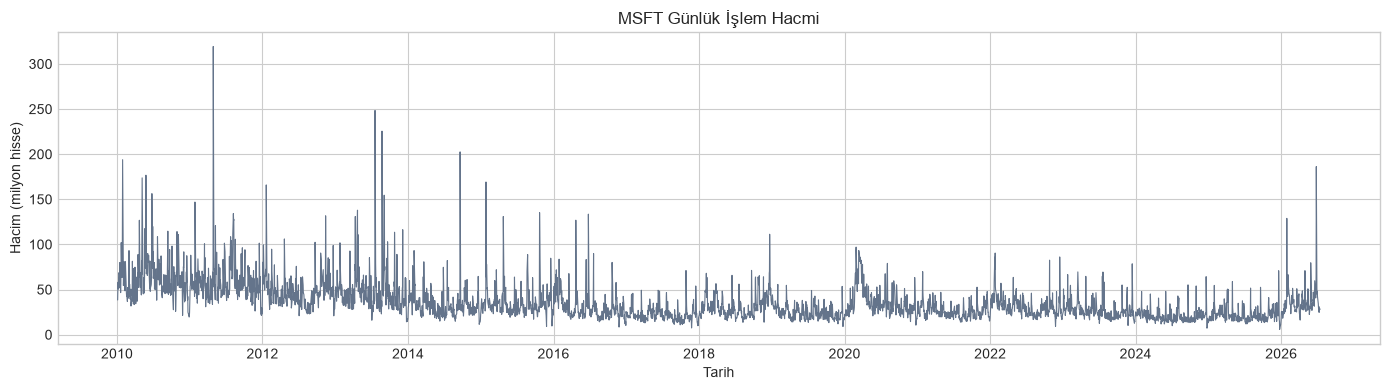

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(data.index, data["Volume"] / 1_000_000, color="#64748B", linewidth=0.8)
ax.set(
    title="MSFT Günlük İşlem Hacmi",
    xlabel="Tarih",
    ylabel="Hacim (milyon hisse)",
)
fig.tight_layout()
plt.show()

## 7. Günlük getiriler

Fiyat seviyesi zaman içinde büyük ölçüde değiştiği için ardışık günleri yüzde değişimle karşılaştırmak daha anlamlıdır. Basit günlük getiri şu şekilde hesaplanır:

$$r_t = \frac{P_t}{P_{t-1}} - 1$$

Burada $P_t$, $t$ günündeki düzeltilmiş kapanış fiyatıdır. İlk günün önceki gözlemi olmadığı için getiri serisi fiyat serisinden bir satır daha kısadır.

In [11]:
daily_returns = data["Close"].pct_change().dropna()

return_summary = pd.Series(
    {
        "Gözlem sayısı": len(daily_returns),
        "Ortalama günlük getiri (%)": daily_returns.mean() * 100,
        "Günlük standart sapma (%)": daily_returns.std() * 100,
        "Yıllıklandırılmış oynaklık (%)": daily_returns.std() * (252**0.5) * 100,
        "Pozitif gün oranı (%)": daily_returns.gt(0).mean() * 100,
        "En düşük günlük getiri (%)": daily_returns.min() * 100,
        "En yüksek günlük getiri (%)": daily_returns.max() * 100,
    },
    name="Değer",
)
return_summary.to_frame()

,Değer
Gözlem sayısı,"4,155.0000"
Ortalama günlük getiri (%),0.0810
Günlük standart sapma (%),1.6244
Yıllıklandırılmış oynaklık (%),25.7868
Pozitif gün oranı (%),52.2503
En düşük günlük getiri (%),-14.7391
En yüksek günlük getiri (%),14.2169


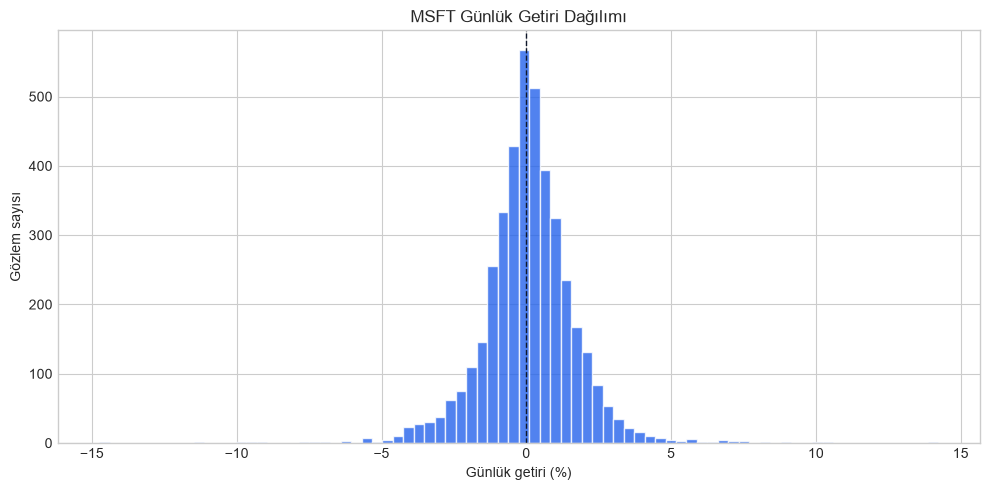

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(daily_returns * 100, bins=80, color="#2563EB", alpha=0.8, edgecolor="white")
ax.axvline(0, color="#0F172A", linestyle="--", linewidth=1)
ax.set(
    title="MSFT Günlük Getiri Dağılımı",
    xlabel="Günlük getiri (%)",
    ylabel="Gözlem sayısı",
)
fig.tight_layout()
plt.show()

## 8. Hareketli oynaklık

Oynaklık, getirilerin ne kadar değişken olduğunu ifade eder. Burada günlük getirilerin 20 işlem günlük hareketli standart sapmasını hesaplayıp yaklaşık 252 işlem günü varsayımıyla yıllıklandırıyoruz. Bu ölçüm geleceği kullanmaz; her tarih yalnızca kendisi ve önceki 19 işlem gününden hesaplanır.

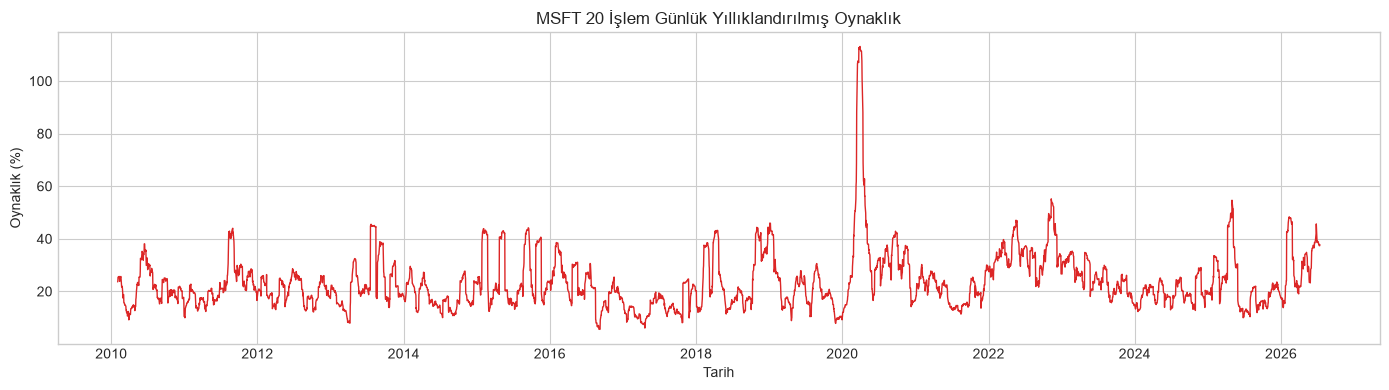

In [13]:
rolling_volatility_20d = daily_returns.rolling(window=20).std() * (252**0.5) * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(
    rolling_volatility_20d.index,
    rolling_volatility_20d,
    color="#DC2626",
    linewidth=1,
)
ax.set(
    title="MSFT 20 İşlem Günlük Yıllıklandırılmış Oynaklık",
    xlabel="Tarih",
    ylabel="Oynaklık (%)",
)
fig.tight_layout()
plt.show()

## 9. İlk değerlendirme

- Veri kesiti uzun dönemli bir zaman serisi analizi için yeterli sayıda günlük gözlem içeriyor.
- Tarihler kronolojik, benzersiz ve temel alanlar eksiksiz.
- Kapanış fiyatı uzun vadede belirgin biçimde değiştiği için ileride ölçekleme yalnızca eğitim verisine göre yapılmalı.
- Fiyat grafiğindeki güçlü trend, tahmin modelini basit bir son-fiyat baseline'ıyla karşılaştırmanın önemini gösteriyor.
- Günlük getirilerin büyük bölümü sıfıra yakın olsa da dağılımda belirgin uç hareketler bulunuyor.
- Oynaklık zaman içinde sabit değil; yüksek oynaklık dönemleri kümeleniyor.